# Image classification
이미지 분류 문제란, 입력 이미지를 미리 정해진 카테고리 중 하나인 라벨로 분류하는 문제입니다. 문제 정의는 매우 간단하지만 다양한 활용 가능성이 있는 컴퓨터 비전 분야의 핵심적인 문제 중의 하나입니다.

| 문제 유형 | 설명 | 예시 |
| ----- | ----- | ----- |
| **이진 분류 (Binary classification)** | 정답 라벨이 두 개(예/아니오, 0/1 중 하나)인 경우 | 건강 검진 수치를 보고 심장 질환이 **있다 / 없다** 를 예측하기 |
| **다중 클래스 분류 (Multi-class classification)** | 정답 라벨이 셋 이상 중 하나인 경우 | 사진 한 장이 **음식 / 사람 / 개** 중 어떤 것인지 분류하기 |
| **다중 라벨 분류 (Multi-label classification)** | 한 데이터에 여러 개의 라벨이 동시에 붙을 수 있는 경우 | 위키피디아 글에 **수학, 과학, 철학**과 같이 여러 카테고리를 동시에 부여하기 |






## Datasets
EuroSAT 데이터 세트는 유럽 지역의 위성 이미지(Sentinel-2)를 보고, 그 위치가 숲, 농경지, 도시, 강, 고속도로 등 중 어떤 종류의 땅인지 분류하는 문제입니다. 총 27,000장의 이미지가 있으며 10개의 클래스로 분류됩니다.

![image](https://raw.githubusercontent.com/phelber/EuroSAT/master/eurosat_overview_small.jpg)




## PyTorch 워크플로우 (PyTorch Workflow)
이미지 분류 모델을 PyTorch로 만들 때의 전형적인 흐름은 다음과 같습니다.

| 단계 | 내용 |
| ----- | ----- |
| **1. 데이터 준비 (Getting data ready)** | 학습에 사용할 데이터를 준비하는 단계입니다. 데이터는 이미지, 텍스트, 센서값 등 무엇이든 될 수 있지만, 여기서는 간단한 예시(예: 개/고양이 이미지)를 사용합니다. |
| **2. 모델 구성 (Building a model)** | 준비된 데이터의 패턴을 학습할 **신경망 모델**을 정의합니다. 이때 **손실 함수(loss function)**, **옵티마이저(optimizer)**, 그리고 학습을 반복 수행할 **훈련 루프(training loop)** 도 함께 설계합니다. |
| **3. 모델 학습 (Fitting the model to data, training)** | 준비된 **훈련 데이터(training data)** 를 이용해 모델이 패턴을 찾도록 학습시킵니다. 이 과정에서 모델 파라미터(가중치)가 반복적으로 업데이트됩니다. |
| **4. 예측 및 평가 (Making predictions and evaluating a model, inference)** | 학습이 끝난 모델을 이용해 **테스트 데이터(test data)** 에 대해 예측을 수행하고, 그 예측 결과가 실제 정답과 얼마나 잘 맞는지 평가합니다. |

## 라이브러리 가져오기

모듈이란 함수나 변수 또는 클래스를 모아 놓은 파일입니다. 모듈은 다른 파이썬 프로그램에서 불러와 사용할 수 있게끔 만든 파이썬 파일이라고도 할 수 있습니다.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from torchvision import datasets
from torchvision import transforms as T

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

import numpy as np
import collections
import matplotlib.pyplot as plt
%matplotlib inline

# GPU(cuda)가 있으면 cuda:0, 없으면 cpu 사용
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## 데이터 로더 정의

데이터 로더(Data Loader)는 디스크에 있는 큰 데이터를 한 번에 다 올리지 못하기 때문에, 조금씩 잘라서(Batch 단위로) 메모리와 GPU로 가져오는 역할을 합니다.
일반적인 데이터 로더의 흐름은 다음과 같습니다.

![image](https://d2.naver.com/content/images/2021/01/efbe9400-5214-11eb-9c67-30fab62770ec.png)

In [ ]:
# EuroSAT 위성 이미지 데이터셋 로드
# https://pytorch.org/vision/stable/datasets.html
data = datasets.EuroSAT('./', download=True)

100%|██████████| 94.3M/94.3M [00:00<00:00, 427MB/s]


In [ ]:
# 클래스 비율을 유지하면서(train/test) 무작위 분할 (8:2)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=2022)

# 전체 인덱스 (0 ~ len(data)-1)
indices = list(range(len(data)))
# 각 샘플의 라벨
y_test = [y for _, y in data]

for train_index, test_index in sss.split(indices, y_test):
    print(len(train_index), len(test_index))

train_set = Subset(data, train_index)
test_datasets = Subset(data, test_index)

# val / test 분할 (각 10%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=2022)
indices = list(range(len(test_datasets)))
y_test = [y for _, y in test_datasets]

for test_index, val_index in sss.split(indices, y_test):
    print(len(test_index), len(val_index))

test_set = Subset(test_datasets, test_index)
val_set = Subset(test_datasets, val_index)

21600 5400
2700 2700


In [ ]:
# Transform (전처리 + 증강) 정의
# 학습용 변환: 회전, 아핀 변환, 좌우 반전 등 데이터 증강 + 텐서 변환
train_transform = T.Compose([
                            T.RandomRotation(15),
                            T.RandomAffine(
                                degrees=0,
                                translate=(0.01, 0.12),
                                shear=(0.01, 0.03),),
                            T.RandomHorizontalFlip(),
                            T.ToTensor(),
])

# 검증/테스트용 변환: 증강 없이 ToTensor만 (항상 동일한 입력)
test_transform = T.Compose([
                            T.ToTensor(),
])

train_set.dataset.transform = train_transform
val_set.dataset.transform = test_transform
test_set.dataset.transform = test_transform

### 배치(Batch)

배치(Batch)는 가중치를 한 번 업데이트하는 데 한 개 이상의 훈련 데이터를 사용하는 부분입니다. 그리고 이 집합에 포함하는 데이터의 양을 배치 크기라고 부릅니다.

![image](http://t1.kakaocdn.net/braincloud/homepage/article_image/820bc25e-dd76-493d-a6a9-4f8d357dce90.png)

In [ ]:
batch_size = 32

# 학습용은 shuffle=True 로 배치를 섞어줌 (일반화에 도움)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

# 검증/테스트는 순서가 중요하지 않으므로 shuffle=False
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)

print(f'number of train dataset: {len(train_set)}')
print(f'number of validation datset: {len(val_set)}')
print(f'number of test dataset: {len(test_set)}')

number of train dataset: 21600
number of validation datset: 2700
number of test dataset: 2700


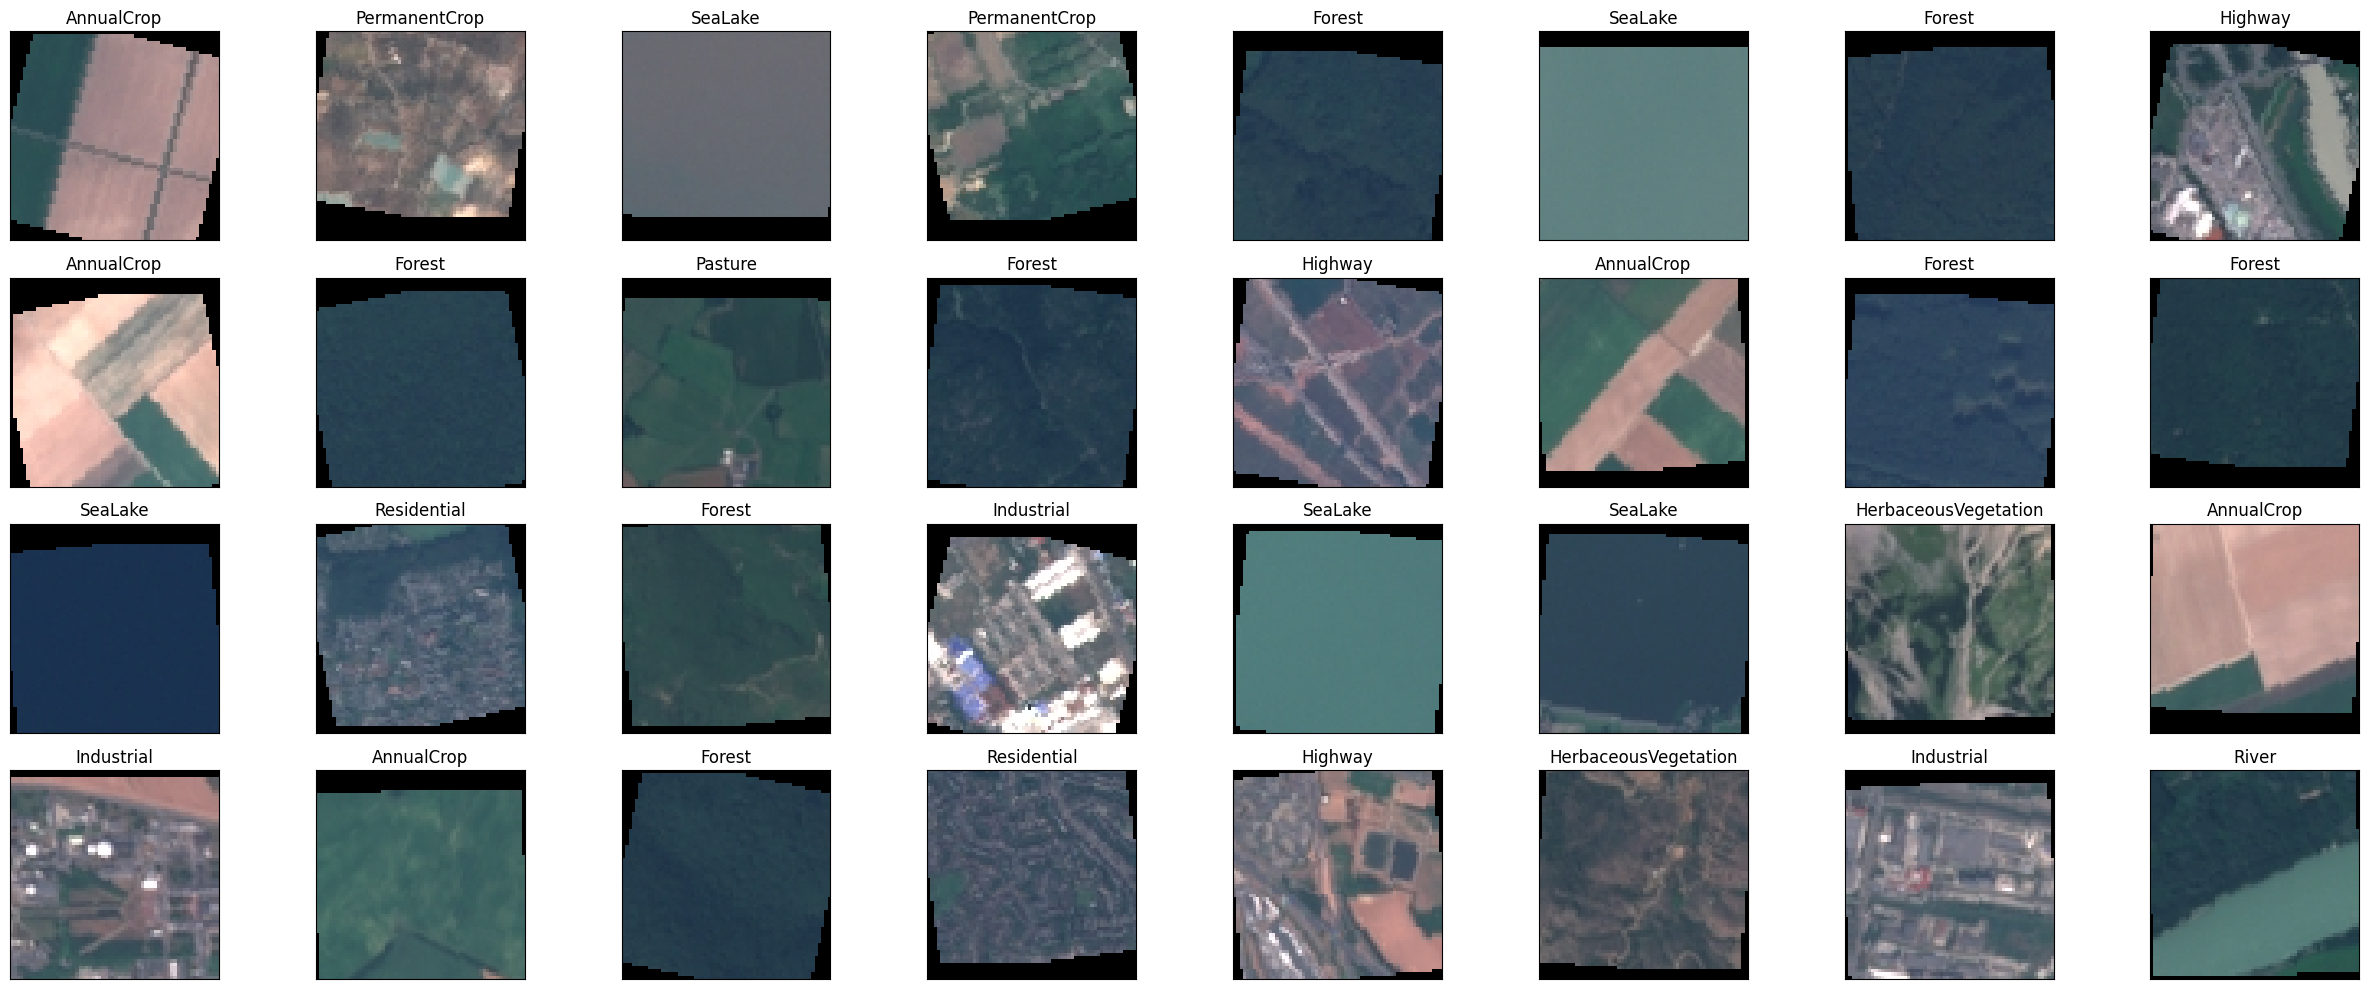

In [ ]:
# DataLoader에서 배치 하나 가져오기
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

batch_size_actual = images.shape[0]

fig = plt.figure(figsize=(25, 10))

# 시각화
n_rows = 4
n_cols = max(1, batch_size_actual // 4)

for idx in range(batch_size_actual):
    ax = fig.add_subplot(n_rows, n_cols, idx+1, xticks=[], yticks=[])

    ax.imshow(images[idx].transpose(1, 2, 0))
    ax.set_title(data.classes[labels[idx]])

plt.tight_layout()
plt.show()


## 합성곱 신경망(Convolution Neural Network) 정의
CNN에는 피쳐 추출을 위한 Convolution 모듈(Convolution + ReLU + pooling)과 분류를 위한 Fully connected layer가 있습니다.

![image](https://1drv.ms/i/c/e8be510964623ec1/IQTTz5x3_J6KQ74WOFAb05vOAW9ESjOD3CeYh6UVT9aHzAQ?width=2816&height=1536)



In [ ]:
# CNN 모델 정의
class Net(nn.Module):
    def __init__(self, num_classes=10):
        super(Net, self).__init__()

        # 특징 추출부 (Convolution + BN + ReLU + MaxPool)
        self.features = nn.Sequential(
            # 입력: (3, 64, 64)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3),  # -> (16, 62, 62)
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True),

            nn.Conv2d(16, 32, 3),  # -> (32, 60, 60)
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(2, 2),    # -> (32, 30, 30)

            nn.Conv2d(32, 64, 3),  # -> (64, 28, 28)
            nn.BatchNorm2d(64),
            nn.ReLU6(inplace=True),

            nn.Conv2d(64, 128, 3),  # -> (128, 26, 26)
            nn.BatchNorm2d(128),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(2, 2),     # -> (128, 13, 13)

            nn.Conv2d(128, 256, 3),  # -> (256, 11, 11)
            nn.BatchNorm2d(256),
            nn.ReLU6(inplace=True),

            nn.Conv2d(256, 512, 3),  # -> (512, 9, 9)
            nn.BatchNorm2d(512),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(2, 2),      # -> (512, 4, 4)
        )

        # 512 * 4 * 4 = 8192 를 입력으로 받는 분류기(FC layer)
        self.classifier = nn.Sequential(
            nn.Linear(8192, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU6(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU6(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # 합성곱/풀링으로 feature map 추출
        x = self.features(x)
        # 배치 차원만 남기고 나머지 평탄화: (B, 512, 4, 4) -> (B, 8192)
        x = torch.flatten(x, 1)
        # FC 분류기 통과
        x = self.classifier(x)
        return x


net = Net(num_classes=10).to(device)

## 손실 함수와 옵티마이저 정의하기

교차 엔트로피 손실(Cross-Entropy loss)과 Adam를 사용합니다.

---

### 손실함수(Loss Function)

손실 함수는 실제 결과와 비교해서 예측된 결과와의 차이를 반환합니다.

---

### 옵티마이저(Optimizer)

옵티마이저(Optimizer)는 트레이닝 중에 모델의 가충치를 조정하여서 예측을 최대한 정확하고 최적화시키는 방법입니다. 옵티마이저는 손실 함수(loss function)의 값에 따라서 모델과 손실함수를 업데이트를 합니다. 손실 함수는 올바른 방향으로 또는 잘못된 방향으로 이동할 때 옵티마이저에게 알려주는 안내 기능입니다.

![image](https://ml-cheatsheet.readthedocs.io/en/latest/_images/optimizers.gif)

In [ ]:
# 손실 함수 / 옵티마이저
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(net.parameters(), lr=0.0001)

## 신경망 학습하기

In [ ]:
# 학습 루프
for epoch in range(5):

    train_loss = 0.0
    train_correct = 0
    val_loss = 0.0
    val_correct = 0

    # (1) 학습
    net.train()

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # 매 step마다 gradient 초기화
        optimizer.zero_grad()

        # 순전파(forward propagation)
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        # 역전파(backward propagation) + 파라미터 업데이트
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
        train_loss += loss.item() * inputs.size(0)

    train_acc = 100 * train_correct / len(train_loader.dataset)
    train_loss = train_loss / len(train_loader.dataset)

    # (2) 검증
    net.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()

    val_acc = 100 * val_correct / len(val_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)

    print(f'Epoch: {epoch + 1} - '
          f'Train Acc: {train_acc:.2f} - Train Loss: {train_loss:.4f} - '
          f'Val Acc: {val_acc:.2f} - Val Loss: {val_loss:.4f}')

print('Finished Training')

Epoch: 1 - Train Acc: 68.08 - Train Loss: 0.9411 - Val Acc: 79.59 - Val Loss: 0.6049
Epoch: 2 - Train Acc: 76.81 - Train Loss: 0.6722 - Val Acc: 84.11 - Val Loss: 0.4765
Epoch: 3 - Train Acc: 81.01 - Train Loss: 0.5552 - Val Acc: 87.07 - Val Loss: 0.3826
Epoch: 4 - Train Acc: 83.81 - Train Loss: 0.4796 - Val Acc: 87.93 - Val Loss: 0.3475
Epoch: 5 - Train Acc: 85.59 - Train Loss: 0.4233 - Val Acc: 88.15 - Val Loss: 0.3494
Finished Training


In [ ]:
# 테스트 세트 정확도
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct / total:.2f} %')

Accuracy of the network on the test images: 87.26 %


In [ ]:
# 클래스별 정확도
correct_pred = {classname: 0 for classname in data.classes}
total_pred = {classname: 0 for classname in data.classes}

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = net(inputs)

        _, predictions = torch.max(outputs, 1)

        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[data.classes[label]] += 1
            total_pred[data.classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: AnnualCrop is 92.3 %
Accuracy for class: Forest is 94.3 %
Accuracy for class: HerbaceousVegetation is 87.3 %
Accuracy for class: Highway is 89.6 %
Accuracy for class: Industrial is 92.4 %
Accuracy for class: Pasture is 91.0 %
Accuracy for class: PermanentCrop is 59.2 %
Accuracy for class: Residential is 97.7 %
Accuracy for class: River is 70.8 %
Accuracy for class: SeaLake is 96.7 %


# 참조

---

https://d2.naver.com/helloworld/3773258  
https://www.kakaobrain.com/blog/113  
https://developers.google.com/machine-learning/practica/image-classification/convolutional-neural-networks  
https://ml-cheatsheet.readthedocs.io/en/latest/optimizers.html  